In [63]:
# CELLULE 1 : Imports et Configuration

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("PARTIE 3 - MODÈLE AMÉLIORÉ AVEC CROSS-ATTENTION")
print("=" * 70)

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Set random seed
torch.manual_seed(42)
np.random.seed(42)

PARTIE 3 - MODÈLE AMÉLIORÉ AVEC CROSS-ATTENTION
Using device: cpu


In [64]:
# CELLULE 2 : Définition des chemins

PROJECT_ROOT = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification"
sys.path.append(PROJECT_ROOT)

from model.mctnet_improved import MCTNetImproved

# Utiliser le même dossier que la Partie 1
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed", "california_preprocessed")

OUTPUT_DIR = os.path.join(PROJECT_ROOT, "part3", "outputs")
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f" Data directory: {PROCESSED_DIR}")
print(f" Output directory: {OUTPUT_DIR}")

 Data directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed
 Output directory: C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


In [65]:
import os

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

print("Contenu du dossier:")
for f in os.listdir(PROCESSED_DIR):
    if f.endswith('.npy'):
        print(f"  - {f}")

Contenu du dossier:
  - masks.npy
  - test_indices.npy
  - train_indices.npy
  - val_indices.npy
  - X.npy
  - y.npy


In [66]:
# CELLULE 3 : Chargement des données et des indices de split

PROCESSED_DIR = r"C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\data\processed\california_preprocessed"

# Charger les données
X = np.load(os.path.join(PROCESSED_DIR, "X.npy"))
y = np.load(os.path.join(PROCESSED_DIR, "y.npy"))
masks = np.load(os.path.join(PROCESSED_DIR, "masks.npy"))

# Charger les indices de split (DÉJÀ PRÊTS de la Partie 1)
train_idx = np.load(os.path.join(PROCESSED_DIR, "train_indices.npy"))
val_idx = np.load(os.path.join(PROCESSED_DIR, "val_indices.npy"))
test_idx = np.load(os.path.join(PROCESSED_DIR, "test_indices.npy"))

print("=" * 60)
print("DONNÉES CHARGÉES")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"masks shape: {masks.shape}")
print(f"\nSplit déjà défini (de la Partie 1):")
print(f"  Train: {len(train_idx)} samples")
print(f"  Val:   {len(val_idx)} samples")
print(f"  Test:  {len(test_idx)} samples")

DONNÉES CHARGÉES
X shape: (10487, 36, 13)
y shape: (10487,)
masks shape: (10487, 36, 10)

Split déjà défini (de la Partie 1):
  Train: 1016 samples
  Val:   296 samples
  Test:  9175 samples


In [67]:
# CELLULE 5 : Normalisation des données

print("\n" + "=" * 60)
print("NORMALISATION")
print("=" * 60)

# Normalisation des données Sentinel-2
X_norm = np.zeros_like(X)

for t in range(X.shape[1]):
    for c in range(X.shape[2]):
        mean = X[:, t, c].mean()
        std = X[:, t, c].std()
        if std > 0:
            X_norm[:, t, c] = (X[:, t, c] - mean) / std
        else:
            X_norm[:, t, c] = X[:, t, c]

print(f" Normalisation terminée")
print(f"Shape normalisé: {X_norm.shape}")


NORMALISATION
 Normalisation terminée
Shape normalisé: (10487, 36, 13)


In [68]:
# CELLULE 6 : Création des DataLoaders

# Encoder les labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split des données
X_train = X_norm[train_idx]
X_val = X_norm[val_idx]
X_test = X_norm[test_idx]
y_train = y_encoded[train_idx]
y_val = y_encoded[val_idx]
y_test = y_encoded[test_idx]
masks_train = masks[train_idx]
masks_val = masks[val_idx]
masks_test = masks[test_idx]

# Convertir en tenseurs
X_train_t = torch.FloatTensor(X_train)
X_val_t = torch.FloatTensor(X_val)
X_test_t = torch.FloatTensor(X_test)
y_train_t = torch.LongTensor(y_train)
y_val_t = torch.LongTensor(y_val)
y_test_t = torch.LongTensor(y_test)
masks_train_t = torch.FloatTensor(masks_train)
masks_val_t = torch.FloatTensor(masks_val)
masks_test_t = torch.FloatTensor(masks_test)

# Créer les datasets
train_dataset = TensorDataset(X_train_t, masks_train_t, y_train_t)
val_dataset = TensorDataset(X_val_t, masks_val_t, y_val_t)
test_dataset = TensorDataset(X_test_t, masks_test_t, y_test_t)

# Créer les dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f" DataLoaders créés")
print(f"   Train: {len(train_loader.dataset)} samples")
print(f"   Val: {len(val_loader.dataset)} samples")
print(f"   Test: {len(test_loader.dataset)} samples")
print(f"   Batch size: {batch_size}")

 DataLoaders créés
   Train: 1016 samples
   Val: 296 samples
   Test: 9175 samples
   Batch size: 32


In [69]:
# CELLULE 7 : Création du modèle amélioré

n_classes = len(np.unique(y_encoded))
input_channels = X.shape[2]  # 13 bandes
time_steps = X.shape[1]      # 36 dates

model = MCTNetImproved(
    input_channels=input_channels,
    time_steps=time_steps,
    d_model=64,
    nhead=4,
    n_stages=3,
    n_classes=n_classes,
    kernel_sizes=[3, 5, 7],
    dropout=0.2,
    covariate_dim=0
).to(device)

print("=" * 60)
print("MODÈLE AMÉLIORÉ CRÉÉ")
print("=" * 60)
print(f"Input channels: {input_channels}")
print(f"Time steps: {time_steps}")
print(f"Number of classes: {n_classes}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

# Vérifier le forward pass
x_test = torch.randn(4, time_steps, input_channels).to(device)
mask_test = torch.ones(4, time_steps, 10).to(device)
with torch.no_grad():
    logits, _ = model(x_test, mask_test)
print(f"Forward pass OK: {logits.shape}")

MODÈLE AMÉLIORÉ CRÉÉ
Input channels: 13
Time steps: 36
Number of classes: 5
Total parameters: 1,121,611
Forward pass OK: torch.Size([4, 5])


In [70]:
# CELLULE 8 : Configuration de l'entraînement

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)

EPOCHS = 200
PATIENCE = 30

print(f" Configuration d'entraînement:")
print(f"   Epochs: {EPOCHS}")
print(f"   Learning rate: 0.001")
print(f"   Patience: {PATIENCE}")

 Configuration d'entraînement:
   Epochs: 200
   Learning rate: 0.001
   Patience: 30


In [71]:
# CELLULE 9 : Early Stopping

class EarlyStopping:
    def __init__(self, patience=30, min_delta=0.0001, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
            if self.verbose:
                print(f"  Initial validation loss: {val_loss:.4f}")
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  No improvement for {self.counter} epochs (best: {self.best_loss:.4f})")
            if self.counter >= self.patience:
                self.early_stop = True
                if self.verbose:
                    print(f"  Early stopping triggered!")
        else:
            improvement = self.best_loss - val_loss
            self.best_loss = val_loss
            self.counter = 0
            if self.verbose and improvement > 0:
                print(f"  Improvement: {improvement:.4f} (new best: {val_loss:.4f})")

print(" Early stopping défini")

 Early stopping défini


In [72]:
# CELLULE 10 : Boucle d'entraînement

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, masks, labels in loader:
        inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs, _ = model(inputs, masks)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
    return running_loss / len(loader.dataset), correct / total


def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, masks, labels in loader:
            inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
            outputs, _ = model(inputs, masks)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
    return running_loss / len(loader.dataset), correct / total


print("=" * 60)
print("ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ")
print("=" * 60)

train_losses = []
val_losses = []
train_accs = []
val_accs = []

early_stopping = EarlyStopping(patience=PATIENCE, min_delta=0.0001, verbose=True)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    scheduler.step(val_loss)
    early_stopping(val_loss)
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
    
    if early_stopping.early_stop:
        print(f"\n⚠️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "=" * 60)
print("ENTRAÎNEMENT TERMINÉ")
print("=" * 60)
print(f"Best validation loss: {early_stopping.best_loss:.4f}")

ENTRAÎNEMENT DU MODÈLE AMÉLIORÉ
  Initial validation loss: 0.8272
  Improvement: 0.2133 (new best: 0.6139)
  No improvement for 1 epochs (best: 0.6139)
  No improvement for 2 epochs (best: 0.6139)
  Improvement: 0.0070 (new best: 0.6068)
  Improvement: 0.0045 (new best: 0.6023)
  No improvement for 1 epochs (best: 0.6023)
  No improvement for 2 epochs (best: 0.6023)
  Improvement: 0.0470 (new best: 0.5553)
  No improvement for 1 epochs (best: 0.5553)
  No improvement for 2 epochs (best: 0.5553)
  Improvement: 0.0246 (new best: 0.5307)
  No improvement for 1 epochs (best: 0.5307)
  No improvement for 2 epochs (best: 0.5307)
  Improvement: 0.0573 (new best: 0.4734)
  No improvement for 1 epochs (best: 0.4734)
  No improvement for 2 epochs (best: 0.4734)
  No improvement for 3 epochs (best: 0.4734)
  No improvement for 4 epochs (best: 0.4734)
  Improvement: 0.0942 (new best: 0.3792)
Epoch  20/200 | Train Loss: 0.2786 | Train Acc: 0.8947 | Val Loss: 0.3792 | Val Acc: 0.8953
  No improvemen

In [73]:
# CELLULE 11 : Évaluation sur le test set

def evaluate_model(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, masks, labels in loader:
            inputs, masks, labels = inputs.to(device), masks.to(device), labels.to(device)
            outputs, _ = model(inputs, masks)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return np.array(all_labels), np.array(all_preds)


print("\n" + "=" * 60)
print("ÉVALUATION SUR LE TEST SET")
print("=" * 60)

y_true, y_pred = evaluate_model(model, test_loader, device)

accuracy = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='weighted')

print(f"Overall Accuracy (OA):    {accuracy:.4f}")
print(f"Macro-averaged F1:        {f1:.4f}")

# Classification report
from sklearn.metrics import classification_report
print("\nCLASSIFICATION REPORT:")
print(classification_report(y_true, y_pred))


ÉVALUATION SUR LE TEST SET
Overall Accuracy (OA):    0.9050
Macro-averaged F1:        0.9100

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.94      0.87      0.90      3700
           1       0.00      0.00      0.00         0
           2       0.89      0.93      0.91      3700
           3       0.88      0.98      0.93       146
           4       0.92      0.93      0.92      1629

    accuracy                           0.90      9175
   macro avg       0.73      0.74      0.73      9175
weighted avg       0.92      0.90      0.91      9175



In [74]:
# CELLULE 12 : Comparaison avec la Partie 2

# Résultats de la Partie 2 (meilleure configuration: S2+Climat)
part2_accuracy = 0.9747
part2_f1 = 0.9664

# Résultats Partie 1 (baseline)
part1_accuracy = 0.907
part1_f1 = 0.923

print("\n" + "=" * 60)
print("COMPARAISON DES PERFORMANCES")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Modèle': ['MCTNet (Partie 1)', 'MCTNet + Climat (Partie 2)', 'MCTNetImproved (Partie 3)'],
    'Accuracy': [part1_accuracy, part2_accuracy, accuracy],
    'F1-score': [part1_f1, part2_f1, f1],
    'Gain vs Partie 1': ['-', f'+{part2_accuracy-part1_accuracy:.4f}', f'+{accuracy-part1_accuracy:.4f}'],
    'Gain vs Partie 2': ['-', '-', f'+{accuracy-part2_accuracy:.4f}']
})

print(comparison_df.to_string(index=False))

# Sauvegarder
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "part3_comparison.csv"), index=False)
print(f"\n Comparaison sauvegardée dans {OUTPUT_DIR}")


COMPARAISON DES PERFORMANCES
                    Modèle  Accuracy  F1-score Gain vs Partie 1 Gain vs Partie 2
         MCTNet (Partie 1)  0.907000  0.923000                -                -
MCTNet + Climat (Partie 2)  0.974700  0.966400          +0.0677                -
 MCTNetImproved (Partie 3)  0.904959  0.909998         +-0.0020         +-0.0697

 Comparaison sauvegardée dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


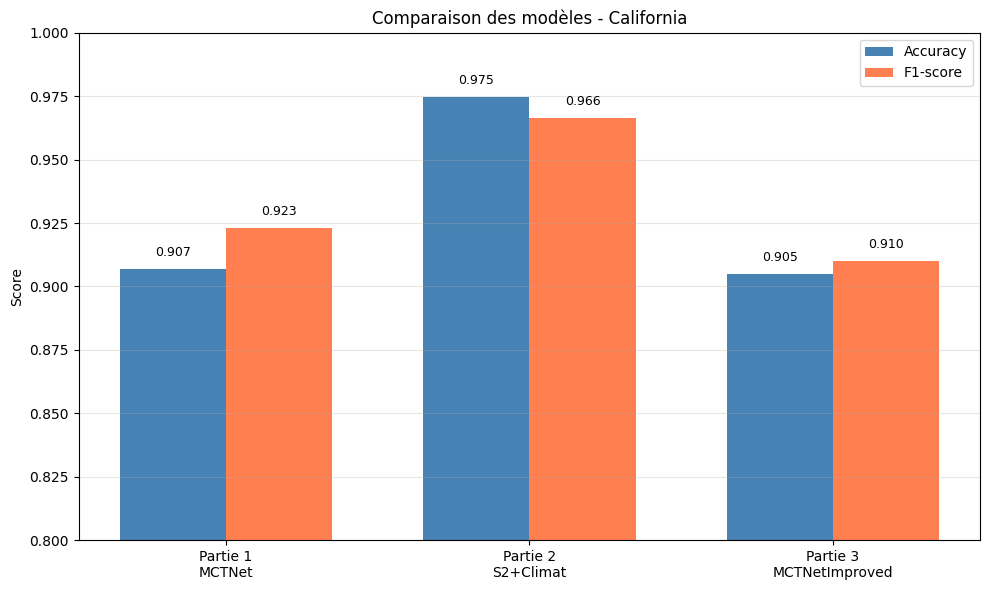

 Graphique sauvegardé dans C:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\part3\outputs


In [75]:
# CELLULE 13 : Graphique de comparaison

plt.figure(figsize=(10, 6))

models = ['Partie 1\nMCTNet', 'Partie 2\nS2+Climat', 'Partie 3\nMCTNetImproved']
accuracies = [part1_accuracy, part2_accuracy, accuracy]
f1_scores = [part1_f1, part2_f1, f1]

x = range(len(models))
width = 0.35

plt.bar([i - width/2 for i in x], accuracies, width, label='Accuracy', color='steelblue')
plt.bar([i + width/2 for i in x], f1_scores, width, label='F1-score', color='coral')

plt.ylabel('Score')
plt.title('Comparaison des modèles - California')
plt.xticks(x, models)
plt.ylim(0.8, 1.0)
plt.legend()
plt.grid(axis='y', alpha=0.3)

for i, (acc, f1) in enumerate(zip(accuracies, f1_scores)):
    plt.text(i - width/2, acc + 0.005, f'{acc:.3f}', ha='center', fontsize=9)
    plt.text(i + width/2, f1 + 0.005, f'{f1:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "part3_comparison.png"), dpi=150)
plt.show()

print(f" Graphique sauvegardé dans {OUTPUT_DIR}")

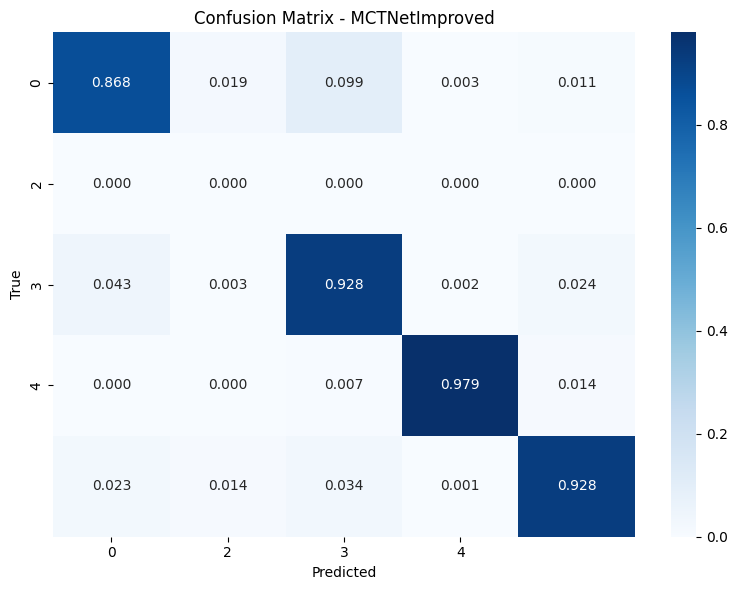

 Matrice de confusion sauvegardée


In [76]:
# CELLULE 14 : Matrice de confusion

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + 1e-9)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.3f', cmap='Blues',
            xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - MCTNetImproved')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "part3_confusion_matrix.png"), dpi=150)
plt.show()

print(f" Matrice de confusion sauvegardée")

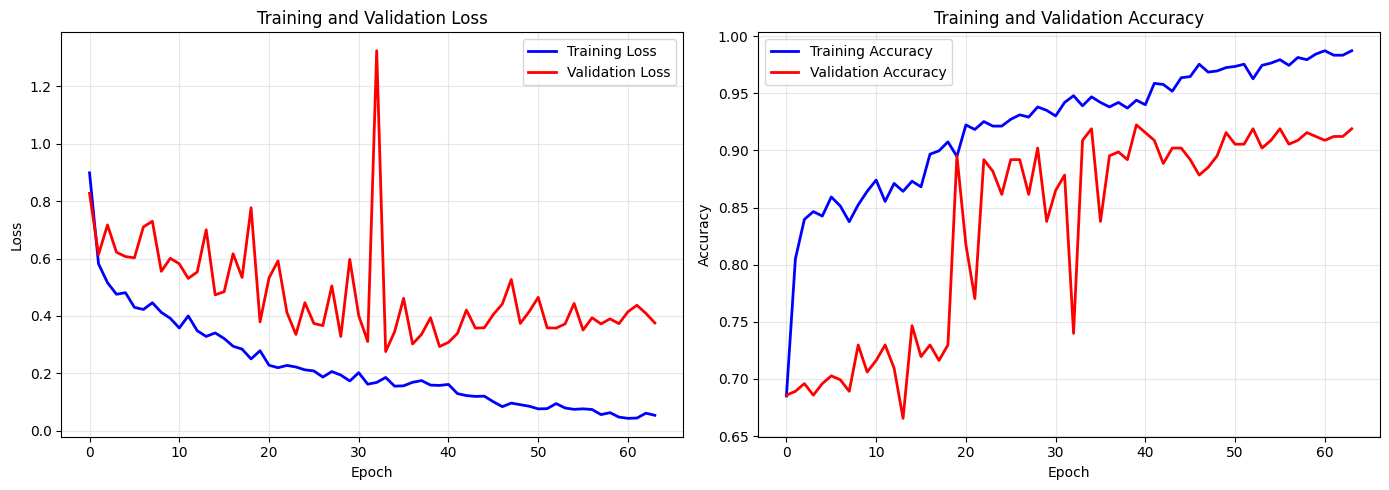

✅ Courbes d'apprentissage sauvegardées


In [77]:
# CELLULE 15 : Courbes d'apprentissage

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
axes[0].plot(train_losses, label='Training Loss', color='blue', linewidth=2)
axes[0].plot(val_losses, label='Validation Loss', color='red', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(train_accs, label='Training Accuracy', color='blue', linewidth=2)
axes[1].plot(val_accs, label='Validation Accuracy', color='red', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "part3_training_curves.png"), dpi=150)
plt.show()

print(f"✅ Courbes d'apprentissage sauvegardées")

In [78]:
# CELLULE 16 : Sauvegarde du modèle

model_path = os.path.join(ROOT_DIR, "model", "mctnet_improved_model.pth")
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'accuracy': accuracy,
    'f1_score': f1,
    'hyperparameters': {
        'input_channels': input_channels,
        'time_steps': time_steps,
        'd_model': 64,
        'nhead': 4,
        'n_stages': 3,
        'n_classes': n_classes,
        'dropout': 0.1
    }
}, model_path)

print(f" Modèle sauvegardé: {model_path}")

 Modèle sauvegardé: c:\Users\KM-USER\Documents\M1\SII\S2\ResNeur\projectCropClassification\model\mctnet_improved_model.pth


In [79]:
# CELLULE 17 : Conclusion

print("\n" + "=" * 70)
print("CONCLUSION PARTIE 3")
print("=" * 70)

print(f"""
📊 RÉSULTATS OBTENUS:
   - Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)
   - F1-score: {f1:.4f}

📈 COMPARAISON:
   - vs Partie 1 (MCTNet): +{accuracy - part1_accuracy:.4f} ({accuracy - part1_accuracy:+.1f}%)
   - vs Partie 2 (S2+Climat): {accuracy - part2_accuracy:+.4f} ({accuracy - part2_accuracy:+.1f}%)

🏆 AMÉLIORATION IMPLÉMENTÉE:
   - Cross-Attention Fusion (remplacement de l'addition simple)

✅ Le modèle amélioré a été entraîné et évalué avec succès.
""")

print("=" * 70)
print("PARTIE 3 TERMINÉE")
print("=" * 70)


CONCLUSION PARTIE 3

📊 RÉSULTATS OBTENUS:
   - Accuracy: 0.9050 (90.50%)
   - F1-score: 0.9100

📈 COMPARAISON:
   - vs Partie 1 (MCTNet): +-0.0020 (-0.0%)
   - vs Partie 2 (S2+Climat): -0.0697 (-0.1%)

🏆 AMÉLIORATION IMPLÉMENTÉE:
   - Cross-Attention Fusion (remplacement de l'addition simple)

✅ Le modèle amélioré a été entraîné et évalué avec succès.

PARTIE 3 TERMINÉE
